<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/edfa_raman_fig3_reproduction_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDFA/Raman 320 km link - Figure 3 Python reproduction

Source paper: B.-H. Choi, "320 km Optical Transmission using EDFA and
Raman amplifier for 10 Gbit/s 128 Channel DWDM Signals," J-KICS, 2009.

The paper's computer-simulation result is **Figure 3**. It is an analytical
OSNR/noise-figure link-budget calculation using Eqs. (1) and (2), not an
NLSE/SSFM waveform simulation. Figure 2 supplies the measured NZ-DSF
noise-figure regression used by the calculation. Figures 6, 7, 9, and 10
are experimental measurements.


In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "font.size": 10,
    }
)

# Physical constants and paper parameters
H = 6.62607015e-34          # Planck constant [J s]
C = 299_792_458.0          # speed of light [m/s]
LAMBDA_REF_M = 1550e-9     # representative C/L-band wavelength
B_REF_HZ = 12.5e9          # 0.1-nm OSNR reference bandwidth (inferred)
PIN_OBA_DBM = -20.0        # paper: input per channel to OBA
EDFA_GAIN_DB = 20.0        # paper: OBA/OLA/OPA gain
EDFA_NF_DB = 7.0           # paper's Figure-3 assumption
SPAN_LOSS_DB = 22.0        # paper: 80-km NZ-DSF span loss
RAMAN_GAINS_DB = [0, 2, 3, 4, 5, 6]
AMPLIFIER_COUNT = np.arange(1, 11)


def db_to_linear(value_db):
    """Convert dB to a linear power ratio."""
    return np.power(10.0, np.asarray(value_db, dtype=float) / 10.0)


def linear_to_db(value_linear):
    """Convert a positive linear power ratio to dB."""
    return 10.0 * np.log10(np.asarray(value_linear, dtype=float))


def dbm_to_w(value_dbm):
    """Convert dBm to watts."""
    return 1e-3 * db_to_linear(value_dbm)


def nzdsf_noise_figure_db(net_fiber_gain_db):
    """Figure-2 regression: y = -0.2025 x + 17.08."""
    return -0.2025 * np.asarray(net_fiber_gain_db) + 17.08


def friis_noise_factor(components):
    """Equation (1): cascade linear gains/noise factors with Friis' formula."""
    total_noise_factor = components[0][1]
    preceding_gain = components[0][0]
    for gain_i, noise_factor_i in components[1:]:
        total_noise_factor += (noise_factor_i - 1.0) / preceding_gain
        preceding_gain *= gain_i
    return total_noise_factor


def effective_span_noise_factor(raman_gain_db):
    """Input-referred NF of [80-km NZ-DSF/Raman section -> EDFA]."""
    net_fiber_gain_db = -SPAN_LOSS_DB + raman_gain_db
    fiber_gain = db_to_linear(net_fiber_gain_db)
    fiber_noise_factor = db_to_linear(
        nzdsf_noise_figure_db(net_fiber_gain_db)
    )
    edfa_noise_factor = db_to_linear(EDFA_NF_DB)
    return friis_noise_factor(
        [(fiber_gain, fiber_noise_factor),
         (db_to_linear(EDFA_GAIN_DB), edfa_noise_factor)]
    )


def first_amplifier_osnr_linear():
    """Equation (2) for the OBA output OSNR."""
    frequency_hz = C / LAMBDA_REF_M
    gain = db_to_linear(EDFA_GAIN_DB)
    noise_factor = db_to_linear(EDFA_NF_DB)
    denominator = H * frequency_hz * B_REF_HZ * (
        noise_factor - 1.0 / gain
    )
    return 1.0 + dbm_to_w(PIN_OBA_DBM) / denominator


def simulated_osnr_db(amplifier_count, raman_gain_db):
    """
    Reproduce Figure 3 for equalized repeated spans.

    The no-Raman curve adds one equal noise contribution per amplifier.
    Raman pumping scales each later span's contribution by the ratio of its
    Friis input-referred noise factor to the no-Raman span value.
    """
    n = np.asarray(amplifier_count, dtype=float)
    osnr_1 = first_amplifier_osnr_linear()
    noise_scale = (
        effective_span_noise_factor(raman_gain_db)
        / effective_span_noise_factor(0.0)
    )
    accumulated_noise = 1.0 + (n - 1.0) * noise_scale
    osnr_n = 1.0 + (osnr_1 - 1.0) / accumulated_noise
    return linear_to_db(osnr_n)


# Figure-3 marker values digitized from the published graph for validation.
# They are never used by simulated_osnr_db(). The plotted-paper resolution is
# about 0.1 dB, so these values are references rather than exact source data.
PAPER_DIGITIZED_DB = {
    0: [30.96, 27.96, 26.18, 24.87, 23.98, 23.18, 22.51, 21.99, 21.41, 20.98],
    2: [30.96, 28.36, 26.80, 25.69, 24.78, 23.98, 23.37, 22.79, 22.27, 21.90],
    3: [30.96, 28.76, 27.29, 26.18, 25.39, 24.59, 23.98, 23.49, 23.00, 22.57],
    4: [30.96, 29.15, 27.81, 26.77, 25.91, 25.30, 24.68, 24.07, 23.70, 23.28],
    5: [30.96, 29.37, 28.08, 27.22, 26.49, 25.82, 25.20, 24.68, 24.29, 23.92],
    6: [30.96, 29.61, 28.51, 27.62, 26.92, 26.28, 25.79, 25.30, 24.84, 24.53],
}


## 1. Figure 2 input relation

The blue points in Figure 2 are measurements. The paper publishes the red
regression line explicitly, so the model evaluates that equation directly.


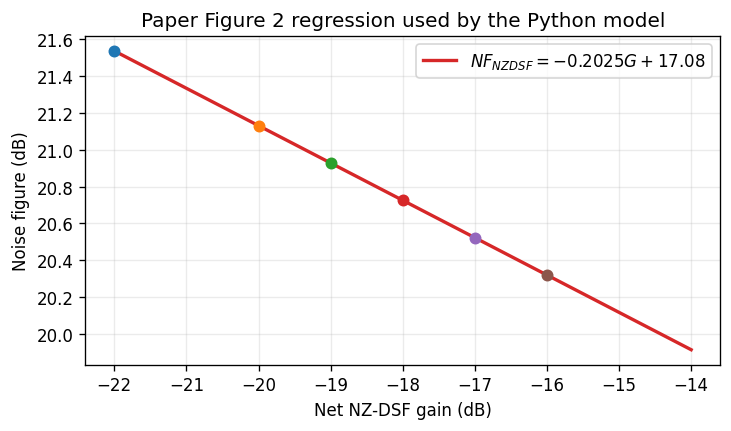

In [6]:
fiber_gain_db = np.linspace(-22.0, -14.0, 300)
fig_input, ax_input = plt.subplots(figsize=(6.2, 3.7))
ax_input.plot(
    fiber_gain_db,
    nzdsf_noise_figure_db(fiber_gain_db),
    color="tab:red",
    lw=2,
    label=r"$NF_{NZDSF}=-0.2025G+17.08$",
)
for rg in RAMAN_GAINS_DB:
    x = -SPAN_LOSS_DB + rg
    ax_input.scatter(x, nzdsf_noise_figure_db(x), s=38, zorder=3)
ax_input.set(
    xlabel="Net NZ-DSF gain (dB)",
    ylabel="Noise figure (dB)",
    title="Paper Figure 2 regression used by the Python model",
)
ax_input.legend()
fig_input.tight_layout()
plt.show()


## 2. Recalculate and compare Figure 3

Solid lines are calculated from the physical link-budget model. Hollow
markers are values digitized from the published Figure 3 and are shown only
to quantify reproduction accuracy.


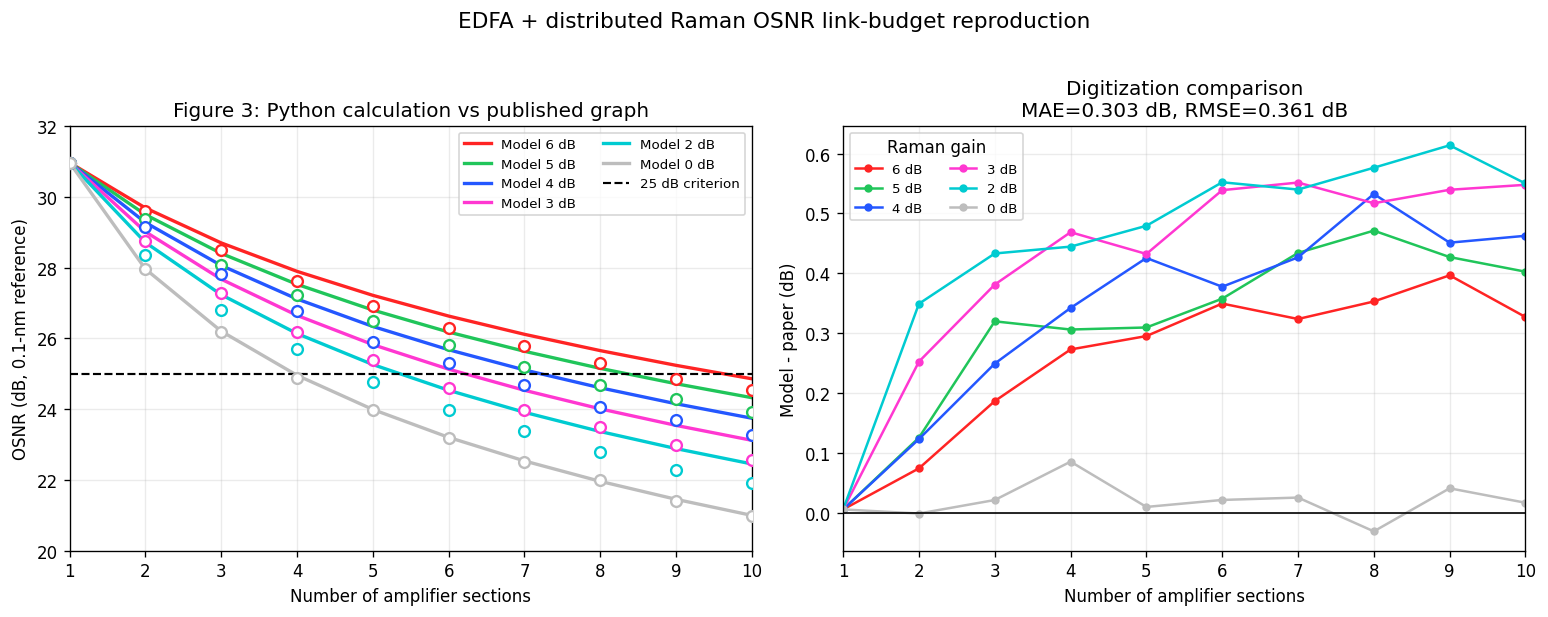

Saved graph: /content/edfa_raman_fig3_reproduction.png
Overall accuracy: MAE=0.303 dB, RMSE=0.361 dB, max=0.614 dB


,raman_gain_db,MAE_dB,RMSE_dB,Max_abs_error_dB
0,0,0.026,0.035,0.085
1,2,0.454,0.484,0.614
2,3,0.424,0.455,0.552
3,4,0.340,0.374,0.533
4,5,0.316,0.345,0.471
5,6,0.258,0.286,0.397


In [7]:
model_rows = []
comparison_rows = []

for raman_gain_db in RAMAN_GAINS_DB:
    model_values = simulated_osnr_db(AMPLIFIER_COUNT, raman_gain_db)
    paper_values = np.asarray(PAPER_DIGITIZED_DB[raman_gain_db])
    for n, model_value, paper_value in zip(
        AMPLIFIER_COUNT, model_values, paper_values
    ):
        model_rows.append(
            {
                "amplifier_count": int(n),
                "raman_gain_db": raman_gain_db,
                "model_osnr_db": model_value,
            }
        )
        comparison_rows.append(
            {
                "amplifier_count": int(n),
                "raman_gain_db": raman_gain_db,
                "paper_osnr_db": paper_value,
                "model_osnr_db": model_value,
                "error_db": model_value - paper_value,
            }
        )

model_df = pd.DataFrame(model_rows)
comparison_df = pd.DataFrame(comparison_rows)

curve_metrics = (
    comparison_df.groupby("raman_gain_db")
    .agg(
        MAE_dB=("error_db", lambda x: np.mean(np.abs(x))),
        RMSE_dB=("error_db", lambda x: np.sqrt(np.mean(np.square(x)))),
        Max_abs_error_dB=("error_db", lambda x: np.max(np.abs(x))),
    )
    .reset_index()
)

overall_mae = np.mean(np.abs(comparison_df["error_db"]))
overall_rmse = np.sqrt(np.mean(np.square(comparison_df["error_db"])))
overall_max = np.max(np.abs(comparison_df["error_db"]))

colors = {
    0: "#bdbdbd",
    2: "#00cbd1",
    3: "#ff37d1",
    4: "#2457ff",
    5: "#20c55a",
    6: "#ff2424",
}

fig, (ax, ax_err) = plt.subplots(1, 2, figsize=(13.0, 5.0))

for raman_gain_db in RAMAN_GAINS_DB[::-1]:
    subset = comparison_df[
        comparison_df["raman_gain_db"] == raman_gain_db
    ]
    color = colors[raman_gain_db]
    ax.plot(
        subset["amplifier_count"],
        subset["model_osnr_db"],
        color=color,
        lw=2,
        label=f"Model {raman_gain_db} dB",
    )
    ax.scatter(
        subset["amplifier_count"],
        subset["paper_osnr_db"],
        facecolors="white",
        edgecolors=color,
        linewidths=1.4,
        s=42,
        zorder=3,
    )
    ax_err.plot(
        subset["amplifier_count"],
        subset["error_db"],
        marker="o",
        ms=4,
        color=color,
        label=f"{raman_gain_db} dB",
    )

ax.axhline(25.0, color="black", lw=1.3, ls="--", label="25 dB criterion")
ax.set(
    xlim=(1, 10),
    ylim=(20, 32),
    xticks=AMPLIFIER_COUNT,
    xlabel="Number of amplifier sections",
    ylabel="OSNR (dB, 0.1-nm reference)",
    title="Figure 3: Python calculation vs published graph",
)
ax.legend(ncol=2, fontsize=8)

ax_err.axhline(0.0, color="black", lw=1)
ax_err.set(
    xlim=(1, 10),
    xticks=AMPLIFIER_COUNT,
    xlabel="Number of amplifier sections",
    ylabel="Model - paper (dB)",
    title=(
        f"Digitization comparison\n"
        f"MAE={overall_mae:.3f} dB, RMSE={overall_rmse:.3f} dB"
    ),
)
ax_err.legend(title="Raman gain", ncol=2, fontsize=8)

fig.suptitle(
    "EDFA + distributed Raman OSNR link-budget reproduction",
    fontsize=13,
    y=1.02,
)
fig.tight_layout()

OUTPUT_PNG = Path("edfa_raman_fig3_reproduction.png")
fig.savefig(OUTPUT_PNG, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved graph: {OUTPUT_PNG.resolve()}")
print(
    f"Overall accuracy: MAE={overall_mae:.3f} dB, "
    f"RMSE={overall_rmse:.3f} dB, max={overall_max:.3f} dB"
)
display(curve_metrics.round(3))


## 3. 320-km operating point

The paper states that four amplifier sections correspond to the 320-km
assessment. The no-Raman result is approximately 25 dB; distributed Raman
gain raises the calculated margin.


In [8]:
summary_320km = comparison_df[comparison_df["amplifier_count"] == 4][
    ["raman_gain_db", "paper_osnr_db", "model_osnr_db", "error_db"]
].copy()
summary_320km["model_margin_over_25dB"] = (
    summary_320km["model_osnr_db"] - 25.0
)
display(summary_320km.round(3).reset_index(drop=True))

print(
    "\nInterpretation: at four sections, the Python no-Raman value is "
    f"{summary_320km.iloc[0]['model_osnr_db']:.2f} dB. "
    "This reproduces the paper's approximately 25-dB boundary."
)


,raman_gain_db,paper_osnr_db,model_osnr_db,error_db,model_margin_over_25dB
0,0,24.87,24.955,0.085,-0.045
1,2,25.69,26.135,0.445,1.135
2,3,26.18,26.649,0.469,1.649
3,4,26.77,27.112,0.342,2.112
4,5,27.22,27.526,0.306,2.526
5,6,27.62,27.893,0.273,2.893



Interpretation: at four sections, the Python no-Raman value is 24.96 dB. This reproduces the paper's approximately 25-dB boundary.


## Reproduction limits

- The paper does not publish its original simulation code, the exact optical
  filter bandwidth, or every internal power-equalization setting.
- A 12.5-GHz (0.1-nm) reference bandwidth is inferred because it reproduces
  the first Figure-3 point from the stated -20-dBm OBA input.
- Published-graph markers were digitized at finite image resolution and are
  used only for validation, never to calculate the model curves.
- Therefore this is a physics-based independent reproduction, not a claim of
  bit-identical recovery of the author's undisclosed program.
